In [1]:
# data_exploration2_lstm.ipynb - Using LSTM Model

# Setup
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LSTM modeling used
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Display settings
pd.set_option('display.max_columns', None)


In [2]:
# Load Dataset
df = pd.read_csv("../data/raw/all_teams.csv")
print("Shape:", df.shape)
df.head()


Shape: (220260, 111)


,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame
0,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,other,0.0000,0.0000,0.0000,42.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.689,0.019,0.069,0.164,0.020,0.521,0.207,0.019,0.019,0.019,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.019,0.000,0.000,0.0,0.0,0.0,1.00,1.0,1.000,0.0,0.017,0.000,0.000,0.037,0.037,0.037,0
1,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,all,0.4596,0.6408,0.6310,3600.0,37.733,2.287,2.842,8.155,1.134,22.530,16.054,2.249,2.396,2.357,41.0,12.0,13.0,66.0,2.0,1.0,0.0,14.0,2.0,18.0,16.0,39.0,51.0,4.0,8.0,30.0,16.0,19.0,8.0,44.0,8.0,1.0,1.040,0.811,0.435,1.0,0.0,1.0,68.292,53.0,54.697,4.0,0.641,0.014,0.029,2.899,3.030,2.980,22.880,2.689,1.780,4.436,0.639,12.626,8.830,2.524,2.607,2.450,21.0,10.0,6.0,37.0,1.0,1.0,0.0,5.0,1.0,8.0,15.0,20.0,30.0,7.0,14.0,32.0,17.0,11.0,7.0,16.0,12.0,3.0,0.599,1.278,0.811,1.0,0.0,0.0,36.14,31.0,30.369,5.0,0.396,0.168,0.168,2.917,2.833,2.714,0
2,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,5on5,0.4857,0.6429,0.6364,2283.0,24.802,1.693,1.724,5.513,0.739,14.650,10.681,1.656,1.803,1.764,28.0,7.0,10.0,45.0,1.0,0.0,0.0,10.0,1.0,14.0,9.0,27.0,34.0,3.0,6.0,19.0,13.0,13.0,7.0,27.0,8.0,0.0,0.882,0.811,0.000,1.0,0.0,0.0,47.292,35.0,36.697,4.0,0.355,0.000,0.000,2.048,2.180,2.130,14.729,1.793,1.117,3.001,0.406,7.737,5.946,1.633,1.711,1.559,11.0,9.0,5.0,25.0,1.0,1.0,0.0,4.0,1.0,4.0,9.0,10.0,19.0,7.0,14.0,18.0,13.0,9.0,5.0,12.0,6.0,2.0,0.498,0.689,0.606,1.0,0.0,0.0,24.14,20.0,19.369

In [3]:
# Explore Columns
df.info()
df.describe().T.head(10)

# check sample columns
df.columns.tolist()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220260 entries, 0 to 220259
Columns: 111 entries, team to playoffGame
dtypes: float64(100), int64(4), object(7)
memory usage: 186.5+ MB


['team',
 'season',
 'name',
 'gameId',
 'playerTeam',
 'opposingTeam',
 'home_or_away',
 'gameDate',
 'position',
 'situation',
 'xGoalsPercentage',
 'corsiPercentage',
 'fenwickPercentage',
 'iceTime',
 'xOnGoalFor',
 'xGoalsFor',
 'xReboundsFor',
 'xFreezeFor',
 'xPlayStoppedFor',
 'xPlayContinuedInZoneFor',
 'xPlayContinuedOutsideZoneFor',
 'flurryAdjustedxGoalsFor',
 'scoreVenueAdjustedxGoalsFor',
 'flurryScoreVenueAdjustedxGoalsFor',
 'shotsOnGoalFor',
 'missedShotsFor',
 'blockedShotAttemptsFor',
 'shotAttemptsFor',
 'goalsFor',
 'reboundsFor',
 'reboundGoalsFor',
 'freezeFor',
 'playStoppedFor',
 'playContinuedInZoneFor',
 'playContinuedOutsideZoneFor',
 'savedShotsOnGoalFor',
 'savedUnblockedShotAttemptsFor',
 'penaltiesFor',
 'penalityMinutesFor',
 'faceOffsWonFor',
 'hitsFor',
 'takeawaysFor',
 'giveawaysFor',
 'lowDangerShotsFor',
 'mediumDangerShotsFor',
 'highDangerShotsFor',
 'lowDangerxGoalsFor',
 'mediumDangerxGoalsFor',
 'highDangerxGoalsFor',
 'lowDangerGoalsFor',
 '

In [4]:
# Feature Engineering

# Target variable: 1 = Win, 0 = Loss
df['win'] = (df['goalsFor'] > df['goalsAgainst']).astype(int)

# Merge Arizona with Utah due to the team relocation
df['team'] = df['team'].replace({'ARI': 'UTA'})

# Filter to keep only seasons from 2010 onward
df_recent = df[df['season'] >= 2010].reset_index(drop=True)
print("Filtered recent seasons (>= 2010):", len(df_recent))
print("Unique seasons:", df_recent['season'].unique())

# From the recent data, select only rows where situation == 'all'
df_all = df_recent[df_recent['situation'] == 'all'].reset_index(drop=True)
print("\nRows with situation == 'all':", len(df_all))
print("Unique games before cleanup:", df_all['gameId'].nunique())

# Detect and remove bad games, each game should have exactly one winner
game_win_sums = df_all.groupby('gameId')['win'].sum()

# Identify invalid games
bad_game_ids = game_win_sums[game_win_sums != 1].index
print("Bad games detected:", len(bad_game_ids))

# Remove invalid games
df_all = df_all[~df_all['gameId'].isin(bad_game_ids)].reset_index(drop=True)

# Print cleanup summary
print("\n✅ After cleanup:")
print("Total rows:", len(df_all))
print("Unique games:", df_all['gameId'].nunique())
print("Win counts:\n", df_all['win'].value_counts())

# Create performance difference features
df_all['shot_diff'] = df_all['shotsOnGoalFor'] - df_all['shotsOnGoalAgainst']
df_all['penalty_diff'] = df_all['penaltiesFor'] - df_all['penaltiesAgainst']
df_all['shotAttempt_diff'] = df_all['shotAttemptsFor'] - df_all['shotAttemptsAgainst']
df_all['faceOff_diff'] = df_all['faceOffsWonFor'] - df_all['faceOffsWonAgainst']


# Export cleaned DataFrames to ../data/processed/
df_recent.to_csv('../data/processed/recent_teams.csv', index=False)
df_all.to_csv('../data/processed/processed_teams.csv', index=False)

print("\n Saved both files to ../data/processed/:")
print(" - recent_teams.csv  → all data since 2010")
print(" - processed_teams.csv → cleaned + situation == 'all'")

# Preview cleaned data
df_all.head()


Filtered recent seasons (>= 2010): 193940
Unique seasons: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024 2025]

Rows with situation == 'all': 38788
Unique games before cleanup: 19394
Bad games detected: 1697

✅ After cleanup:
Total rows: 35394
Unique games: 17697
Win counts:
 win
1    17697
0    17697
Name: count, dtype: int64

 Saved both files to ../data/processed/:
 - recent_teams.csv  → all data since 2010
 - processed_teams.csv → cleaned + situation == 'all'


,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame,win,shot_diff,penalty_diff,shotAttempt_diff,faceOff_diff
0,NYR,2010,NYR,2010020013,NYR,BUF,AWAY,20101009,Team Level,all,0.6494,0.4724,0.4545,3600.0,29.597,4.448,1.721,6.399,0.926,13.764,12.742,4.433,4.751,4.735,28.0,12.0,20.0,60.0,6.0,2.0,1.0,6.0,2.0,8.0,16.0,22.0,34.0,5.0,10.0,25.0,18.0,3.0,5.0,30.0,3.0,7.0,1.015,0.333,3.100,1.0,1.0,4.0,67.484,40.0,44.044,2.0,0.374,0.922,0.922,3.901,4.156,4.148,34.118,2.401,2.174,7.917,1.140,19.541,14.828,2.366,2.207,2.175,36.0,12.0,19.0,67.0,3.0,2.0,0.0,5.0,1.0,18.0,19.0,33.0,45.0,4.0,8.0,30.0,30.0,5.0,15.0,34.0,13.0,1.0,0.780,1.391,0.229,2.0,1.0,0.0,60.988,48.0,43.710,7.0,0.463,0.239,0.239,2.624,2.417,2.382,0,1,-8.0,1.0,-7.0,-5.0
1,NYR,2010,NYR,2010020028,NYR,NYI,AWAY,20101011,Team Level,all,0.4394,0.5526,0.5488,3600.0,32.763,3.099,2.388,8.018,1.423,17.306,12.765,3.055,3.171,3.125,33.0,12.0,18.0,63.0,4.0,3.0,0.0,15.0,2.0,12.0,9.0,29.0,41.0,6.0,15.0,34.0,25.0,7.0,9.0,37.0,5.0,3.0,1.061,0.529,1.510,2.0,0.0,2.0,64.669,45.0,45.988,5.0,0.533,0.169,0.169,3.464,3.550,3.506,26.480,3.953,1.839,5.986,0.893,14.555,9.774,3.692,3.904,3.643,32.0,5.0,14.0,51.0,6.0,3.0,1.0,5.0,1.0,9.0,13.0,26.0,31.0,5.0,11.0,29.0,28.0,15.0,13.0,23.0,9.0,5.0,0.762,1.162,2.029,1.0,1.0,4.0,50.399,37.0,36.554,5.0,0.425,0.600,0.600,3.777,3.736,3.482,0,0,1.0,1.0,12.0,5.0
2,NYR,2010,NYR,2010020049,NYR,TOR,HOME,20101015,Team Level,all,0.4434,0.4602,0.4787,3788.0,31.758,2.306,2.242,7.130,0.964,19.206,13.152,2.213,2.245,2.152,24.0,21.0,7.0,52.0,3.0,2.0,0.0,6.0,1.0,19.0,14.0,21.0,42.0,9.0,21.0,19.0,41.0,7.0,11.0,38.0,6.0,1.0,1.508,0.547,0.251,3.0,0.0,0.0,50.500,45.0,43.921,5.0,0.481,0.316,0.316,2.471,2.396,2.345,34.178,2.895,2.578,7.344,1.183,20.626,14.374,2.809,2.987,2.897,38.0,11

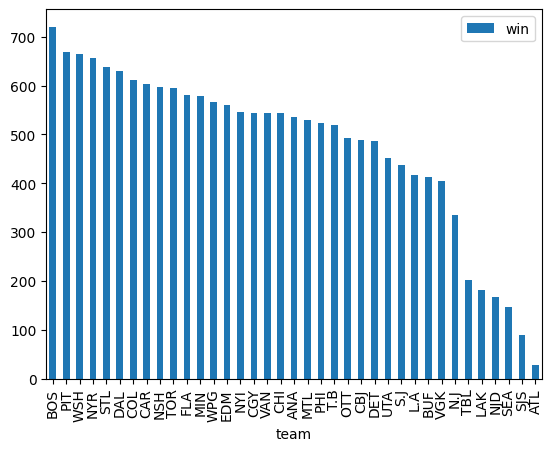

In [5]:
# Visualizations
df_grouped = df_all.groupby('team')['win'].sum().reset_index().sort_values(by='win', ascending=False)

df_grouped.plot.bar(x='team', y='win')
plt.show()


Wins: 17697, Losses: 17697


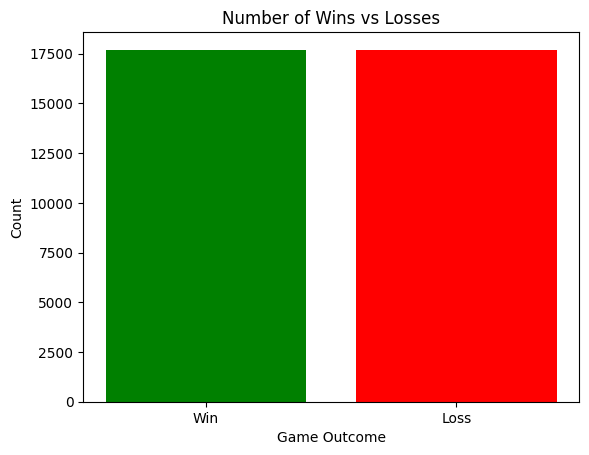

In [6]:
# Exploratory Analysis

# Count wins and losses
win_count = (df_all['win'] == 1).astype(int).sum()
loss_count = (df_all['win'] == 0).astype(int).sum()
print(f"Wins: {win_count}, Losses: {loss_count}")

# Values
categories = ['Win', 'Loss']
counts = [win_count, loss_count]

# Plot
plt.bar(categories, counts, color=['green', 'red'])
plt.title('Number of Wins vs Losses')
plt.xlabel('Game Outcome')
plt.ylabel('Count')
plt.show()


In [7]:
# Final sanity checks

# Check unique teams in recent data
current_teams = df_all['team'].unique()
print("Number of unique teams:", len(current_teams))
print("Teams:", sorted(current_teams))

# Display win counts per team
print(df_all.groupby('team')['win'].agg(['sum', 'count']))

# Check for any NaN values in recent data
print("Any NaNs?", df_all.isna().sum().sum())

# Check for duplicated game-team entries in cleaned data
dup_games = df_all[df_all.duplicated(['gameId', 'team'])]
print("Duplicated rows:", len(dup_games))


Number of unique teams: 37
Teams: ['ANA', 'ATL', 'BOS', 'BUF', 'CAR', 'CBJ', 'CGY', 'CHI', 'COL', 'DAL', 'DET', 'EDM', 'FLA', 'L.A', 'LAK', 'MIN', 'MTL', 'N.J', 'NJD', 'NSH', 'NYI', 'NYR', 'OTT', 'PHI', 'PIT', 'S.J', 'SEA', 'SJS', 'STL', 'T.B', 'TBL', 'TOR', 'UTA', 'VAN', 'VGK', 'WPG', 'WSH']
      sum  count
team            
ANA   535   1127
ATL    29     70
BOS   720   1226
BUF   412   1059
CAR   603   1161
CBJ   488   1099
CGY   544   1111
CHI   543   1158
COL   611   1176
DAL   630   1193
DET   487   1103
EDM   560   1174
FLA   580   1136
L.A   417    825
LAK   182    333
MIN   578   1123
MTL   530   1143
N.J   336    758
NJD   167    338
NSH   597   1160
NYI   546   1125
NYR   657   1211
OTT   493   1109
PHI   524   1098
PIT   669   1191
S.J   438    836
SEA   146    332
SJS    90    314
STL   638   1174
T.B   519    886
TBL   203    358
TOR   594   1143
UTA   451   1082
VAN   544   1116
VGK   405    686
WPG   567   1073
WSH   664   1187
Any NaNs? 0
Duplicated rows: 0


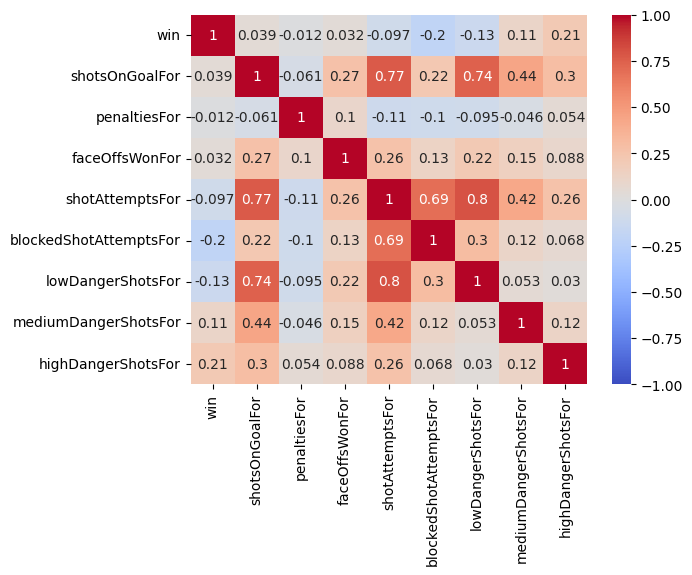

In [8]:
# Correlation heat maps
corr = df_all[['win','shotsOnGoalFor','penaltiesFor', 'faceOffsWonFor', 'shotAttemptsFor', 'blockedShotAttemptsFor', 'lowDangerShotsFor', 'mediumDangerShotsFor', 'highDangerShotsFor']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()


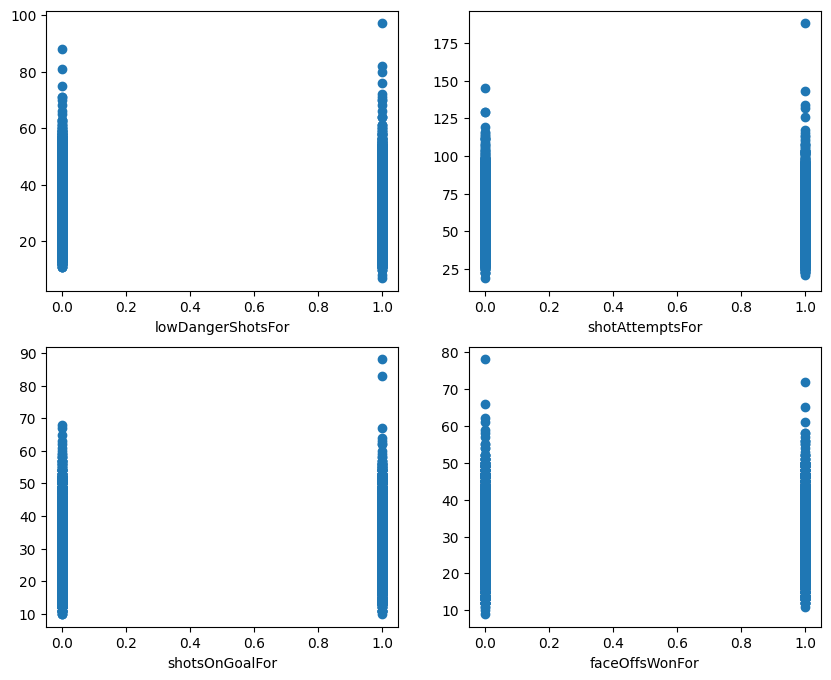

In [9]:
# Scatter plots
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,8))
ax[0,0].scatter(df_all['win'], df_all['lowDangerShotsFor'])
ax[0,1].scatter(df_all['win'], df_all['shotAttemptsFor'])
ax[1,0].scatter(df_all['win'], df_all['shotsOnGoalFor'])
ax[1,1].scatter(df_all['win'], df_all['faceOffsWonFor'])

ax[0,0].set_xlabel('lowDangerShotsFor')
ax[0,1].set_xlabel('shotAttemptsFor')
ax[1,0].set_xlabel('shotsOnGoalFor')
ax[1,1].set_xlabel('faceOffsWonFor')
plt.show()


Since the dataset utilizes exact values for each game, we calculate the average of the (important) features for the model to use for predictions, as we wouldn't have the actual values before the match we would want to predict. 
We also split each feature up into different windows so the model can learn whether more recent games are important, or overall stats:
- average of last 3 games
- average of last 5 games
- average of last 10 games
- average for all games in the season

For LSTM models, we will structure this data as sequences where each sequence represents a team's recent game history.


In [10]:
# Pre-game pipeline: build team-game table from df_recent for LSTM

# Start from team-level rows only
df_pre_raw = df_recent[df_recent["position"] == "Team Level"].copy()

# Get win + date info from ALL-situation rows (one per team-game)
df_pre_win = df_pre_raw[df_pre_raw["situation"] == "all"][[
    "gameId", "playerTeam", "home_or_away", "gameDate", "win"
]].copy()

# Pivot situations (all, 5on5, 5on4, 4on5, other) into columns
df_pre_pivot = df_pre_raw.pivot_table(
    index=["gameId", "playerTeam", "home_or_away"],
    columns="situation",
    aggfunc="first"
)

# Flatten multi-index columns: (stat, situation) -> "stat_situation"
df_pre_pivot.columns = [f"{stat}_{sit}" for stat, sit in df_pre_pivot.columns]
df_pre_pivot = df_pre_pivot.reset_index()

# Merge win + date back in
df_teamgames = df_pre_pivot.merge(
    df_pre_win,
    on=["gameId", "playerTeam", "home_or_away"],
    how="left"
)

print("Team-game table shape:", df_teamgames.shape)
df_teamgames.head()


Team-game table shape: (38788, 545)


,gameId,playerTeam,home_or_away,blockedShotAttemptsAgainst_4on5,blockedShotAttemptsAgainst_5on4,blockedShotAttemptsAgainst_5on5,blockedShotAttemptsAgainst_all,blockedShotAttemptsAgainst_other,blockedShotAttemptsFor_4on5,blockedShotAttemptsFor_5on4,blockedShotAttemptsFor_5on5,blockedShotAttemptsFor_all,blockedShotAttemptsFor_other,corsiPercentage_4on5,corsiPercentage_5on4,corsiPercentage_5on5,corsiPercentage_all,corsiPercentage_other,dZoneGiveawaysAgainst_4on5,dZoneGiveawaysAgainst_5on4,dZoneGiveawaysAgainst_5on5,dZoneGiveawaysAgainst_all,dZoneGiveawaysAgainst_other,dZoneGiveawaysFor_4on5,dZoneGiveawaysFor_5on4,dZoneGiveawaysFor_5on5,dZoneGiveawaysFor_all,dZoneGiveawaysFor_other,faceOffsWonAgainst_4on5,faceOffsWonAgainst_5on4,faceOffsWonAgainst_5on5,faceOffsWonAgainst_all,faceOffsWonAgainst_other,faceOffsWonFor_4on5,faceOffsWonFor_5on4,faceOffsWonFor_5on5,faceOffsWonFor_all,faceOffsWonFor_other,fenwickPercentage_4on5,fenwickPercentage_5on4,fenwickPercentage_5on5,fenwickPercentage_all,fenwickPercentage_other,flurryAdjustedxGoalsAgainst_4on5,flurryAdjustedxGoalsAgainst_5on4,flurryAdjustedxGoalsAgainst_5on5,flurryAdjustedxGoalsAgainst_all,flurryAdjustedxGoalsAgainst_other,flurryAdjustedxGoalsFor_4on5,flurryAdjustedxGoalsFor_5on4,flurryAdjustedxGoalsFor_5on5,flurryAdjustedxGoalsFor_all,flurryAdjustedxGoalsFor_other,flurryScoreVenueAdjustedxGoalsAgainst_4on5,flurryScoreVenueAdjustedxGoalsAgainst_5on4,flurryScoreVenueAdjustedxGoalsAgainst_5on5,flurryScoreVenueAdjustedxGoalsAgainst_all,flurryScoreVenueAdjustedxGoalsAgainst_other,flurryScoreVenueAdjustedxGoalsFor_4on5,flurryScoreVenueAdjustedxGoalsFor_5on4,flurryScoreVenueAdjustedxGoalsFor_5on5,flurryScoreVenueAdjustedxGoalsFor_all,flurryScoreVenueAdjustedxGoalsFor_other,freezeAgainst_4on5,freezeAgainst_5on4,freezeAgainst_5on5,freezeAgainst_all,freezeAgainst_other,freezeFor_4on5,freezeFor_5on4,freezeFor_5on5,freezeFor_all,freezeFor_other,gameDate_4on5,gameDate_5on4,gameDate_5on5,gameDate_all,gameDate_other,giveawaysAgainst_4on5,giveawaysAgainst_5on4,giveawaysAgainst_5on5,giveawaysAgainst_all,giveawaysAgainst_other,giveawaysFor_4on5,giveawaysFor_5on4,giveawaysFor_5on5,giveawaysFor_all,giveawaysFor_other,goalsAgainst_4on5,goalsAgainst_5on4,goalsAgainst_5on5,goalsAgainst_all,goalsAgainst_other,goalsFor_4on5,goalsFor_5on4,goalsFor_5on5,goalsFor_all,goalsFor_other,highDangerGoalsAgainst_4on5,highDangerGoalsAgainst_5on4,highDangerGoalsAgainst_5on5,highDangerGoalsAgainst_all,highDangerGoalsAgainst_other,highDangerGoalsFor_4on5,highDangerGoalsFor_5on4,highDangerGoalsFor_5on5,highDangerGoalsFor_all,highDangerGoalsFor_other,highDangerShotsAgainst_4on5,highDangerShotsAgainst_5on4,highDangerShotsAgainst_5on5,highDangerShotsAgainst_all,highDangerShotsAgainst_other,highDangerShotsFor_4on5,highDangerShotsFor_5on4,highDangerShotsFor_5on5,highDangerShotsFor_all,highDangerShotsFor_other,highDangerxGoalsAgainst_4on5,highDangerxGoalsAgainst_5on4,highDangerxGoalsAgainst_5on5,highDangerxGoalsAgainst_all,highDangerxGoalsAgainst_other,highDangerxGoalsFor_4on5,highDangerxGoalsFor_5on4,highDangerxGoalsFor_5on5,highDangerxGoalsFor_all,highDangerxGoalsFor_other,hitsAgainst_4on5,hitsAgainst_5on4,hitsAgainst_5on5,hitsAgainst_all,hitsAgainst_other,hitsFor_4on5,hitsFor_5on4,hitsFor_5on5,hitsFor_all,hitsFor_other,iceTime_4on5,iceTime_5on4,iceTime_5on5,iceTime_all,iceTime_other,lowDangerGoalsAgainst_4on5,lowDangerGoalsAgainst_5on4,lowDangerGoalsAgainst_5on5,lowDangerGoalsAgainst_all,lowDangerGoalsAgainst_other,lowDangerGoalsFor_4on5,lowDangerGoalsFor_5on4,lowDangerGoalsFor_5on5,lowDangerGoalsFor_all,lowDangerGoalsFor_other,lowDangerShotsAgainst_4on5,lowDangerShotsAgainst_5on4,lowDangerShotsAgainst_5on5,lowDangerShotsAgainst_all,lowDangerShotsAgainst_other,lowDangerShotsFor_4on5,lowDangerShotsFor_5on4,lowDangerShotsFor_5on5,lowDangerShotsFor_all,lowDangerShotsFor_other,lowDangerxGoalsAgainst_4on5,lowDangerxGoalsAgainst_5on4,lowDangerxGoalsAgainst_5on5,lowDangerxGoalsAgainst_all,lowDangerxGoalsAgainst_other,lowDangerxGoa

In [11]:
# Per-game composite stats for LSTM sequences
df_pg = df_teamgames.copy()

# Even-strength (5v5) expected goal differential
df_pg["ES_xG_diff_5v5"] = df_pg["xGoalsFor_5on5"] - df_pg["xGoalsAgainst_5on5"]

# Power-play xG rate (5on4)
df_pg["PP_xG_rate"] = df_pg["xGoalsFor_5on4"] / (df_pg["shotsOnGoalFor_5on4"] + 1)

# Penalty-kill xG allowed rate (4on5) – lower is better
df_pg["PK_xG_allowed_rate"] = df_pg["xGoalsAgainst_4on5"] / (df_pg["shotsOnGoalAgainst_4on5"] + 1)

# Discipline (all situations)
df_pg["penalty_diff_all"] = df_pg["penaltiesFor_all"] - df_pg["penaltiesAgainst_all"]

# Home indicator
df_pg["is_home"] = (df_pg["home_or_away"] == "HOME").astype(int)

# Ensure chronological order within each team
df_pg = df_pg.sort_values(["playerTeam", "gameDate"]).copy()
df_pg["gameDate_dt"] = pd.to_datetime(df_pg["gameDate"], format="%Y%m%d")

df_pg[[
    "playerTeam", "gameDate", "ES_xG_diff_5v5",
    "PP_xG_rate", "PK_xG_allowed_rate", "penalty_diff_all", "is_home", "win"
]].head(12)


,playerTeam,gameDate,ES_xG_diff_5v5,PP_xG_rate,PK_xG_allowed_rate,penalty_diff_all,is_home,win
16,ANA,20101008,0.879,0.008500,0.064000,4.0,0,0
38,ANA,20101009,-1.357,0.056700,0.068000,3.0,0,0
56,ANA,20101011,-1.895,0.041714,0.107476,5.0,0,0
80,ANA,20101013,-0.772,0.068333,0.387000,-2.0,1,1
104,ANA,20101015,0.021,0.149467,0.298429,-3.0,1,0
132,ANA,20101017,-0.376,0.092667,0.005000,-1.0,1,1
156,ANA,20101020,-0.119,0.068429,0.024000,-2.0,0,0
166,ANA,20101021,-1.300,0.006800,0.090143,1.0,0,1
206,ANA,20101023,-2.588,0.002500,0.113800,2.0,0,0
240,ANA,20101026,-1.237,0.128000,0.094077,1.0,0,1


Now that the features have been engineered, we can begin training our LSTM model. The workflow will go like this:
1) Create sequences from team game history (sliding windows of recent games)
2) Split the data into 80/20 chronologically, preserving temporal order
3) Build LSTM model to learn from sequences of team performance
4) Evaluate model with time-series aware metrics


In [12]:
# Prepare features for LSTM sequences
# Select key features for sequence modeling
sequence_features = [
    "ES_xG_diff_5v5",
    "PP_xG_rate",
    "PK_xG_allowed_rate",
    "penalty_diff_all",
    "xGoalsFor_all",
    "xGoalsAgainst_all",
    "shotsOnGoalFor_all",
    "shotsOnGoalAgainst_all",
]

# Clean data: drop rows with missing core features
df_pg_clean = df_pg.dropna(subset=sequence_features + ["win", "gameDate_dt", "playerTeam"]).copy()

# Sort globally by date to maintain chronological order
df_pg_clean = df_pg_clean.sort_values("gameDate_dt").reset_index(drop=True)

print("Cleaned dataset shape:", df_pg_clean.shape)
df_pg_clean[sequence_features + ["playerTeam", "gameDate_dt", "win"]].head()


Cleaned dataset shape: (38788, 551)


,ES_xG_diff_5v5,PP_xG_rate,PK_xG_allowed_rate,penalty_diff_all,xGoalsFor_all,xGoalsAgainst_all,shotsOnGoalFor_all,shotsOnGoalAgainst_all,playerTeam,gameDate_dt,win
0,1.468,0.2450,0.110400,0.0,3.773,2.644,31.0,29.0,CAR,2010-10-07,1
1,1.225,0.0155,0.075000,3.0,3.135,1.469,28.0,24.0,MTL,2010-10-07,0
2,-1.225,0.0750,0.015500,-3.0,1.469,3.135,24.0,28.0,TOR,2010-10-07,1
3,-0.081,0.0130,0.090154,2.0,2.857,4.025,37.0,33.0,CGY,2010-10-07,0
4,-0.374,0.1820,0.204000,1.0,3.390,3.173,27.0,31.0,PHI,2010-10-07,1


In [13]:
# Function to create sequences for LSTM
# Each sequence will be the last N games for a team, predicting the next game outcome

def create_sequences(df, features, sequence_length=10, target_col='win'):
    """
    Create sequences from team game history.
    Each sequence is a sliding window of the last N games for a team.
    """
    sequences = []
    targets = []
    team_ids = []
    
    # Group by team to create sequences for each team separately
    for team in df['playerTeam'].unique():
        team_data = df[df['playerTeam'] == team].sort_values('gameDate_dt').reset_index(drop=True)
        team_features = team_data[features].values
        team_targets = team_data[target_col].values
        
        # Create sequences using sliding window
        for i in range(sequence_length, len(team_data)):
            # Sequence: last N games (excluding current game)
            seq = team_features[i-sequence_length:i]
            # Target: current game outcome
            target = team_targets[i]
            
            sequences.append(seq)
            targets.append(target)
            team_ids.append(team)
    
    return np.array(sequences), np.array(targets), np.array(team_ids)

# Create sequences with sequence_length=10 (last 10 games)
SEQUENCE_LENGTH = 10
X_sequences, y_sequences, team_ids = create_sequences(
    df_pg_clean, 
    sequence_features, 
    sequence_length=SEQUENCE_LENGTH,
    target_col='win'
)

print(f"Sequences shape: {X_sequences.shape}")  # (num_samples, sequence_length, num_features)
print(f"Targets shape: {y_sequences.shape}")
print(f"Number of sequences: {len(X_sequences)}")
print(f"Class distribution: {np.bincount(y_sequences.astype(int))}")


Sequences shape: (38408, 10, 8)
Targets shape: (38408,)
Number of sequences: 38408
Class distribution: [20888 17520]


In [14]:
# Chronological train/test split (preserving temporal order)
# 80% earliest sequences for training, 20% latest for testing
cut = int(len(X_sequences) * 0.8)
X_train_seq, X_test_seq = X_sequences[:cut], X_sequences[cut:]
y_train_seq, y_test_seq = y_sequences[:cut], y_sequences[cut:]

print(f"Training sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")
print(f"Training targets: {y_train_seq.shape}")
print(f"Test targets: {y_test_seq.shape}")

# Standardize features (fit on training data only to avoid data leakage)
scaler = StandardScaler()
# Reshape for scaling: (samples * sequence_length, features)
n_samples_train, seq_len, n_features = X_train_seq.shape
X_train_reshaped = X_train_seq.reshape(-1, n_features)
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_train_seq_scaled = X_train_scaled.reshape(n_samples_train, seq_len, n_features)

# Transform test data using training scaler
n_samples_test = X_test_seq.shape[0]
X_test_reshaped = X_test_seq.reshape(-1, n_features)
X_test_scaled = scaler.transform(X_test_reshaped)
X_test_seq_scaled = X_test_scaled.reshape(n_samples_test, seq_len, n_features)

print(f"\nScaled training sequences shape: {X_train_seq_scaled.shape}")
print(f"Scaled test sequences shape: {X_test_seq_scaled.shape}")


Training sequences: (30726, 10, 8)
Test sequences: (7682, 10, 8)
Training targets: (30726,)
Test targets: (7682,)

Scaled training sequences shape: (30726, 10, 8)
Scaled test sequences shape: (7682, 10, 8)


In [15]:
# Build LSTM Model
# Clear any existing models
keras.backend.clear_session()

# Define LSTM model architecture
model = keras.Sequential([
    # First LSTM layer with dropout for regularization
    layers.LSTM(64, activation='tanh', return_sequences=True, 
                input_shape=(SEQUENCE_LENGTH, len(sequence_features)),
                dropout=0.2, recurrent_dropout=0.2),
    
    # Second LSTM layer
    layers.LSTM(32, activation='tanh', return_sequences=False,
                dropout=0.2, recurrent_dropout=0.2),
    
    # Dense layers for final prediction
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # Binary classification output
])

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()


c:\Users\the4b\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train LSTM model
# Set up early stopping and model checkpoint callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# Train the model
history = model.fit(
    X_train_seq_scaled,
    y_train_seq,
    batch_size=64,
    epochs=50,
    validation_split=0.2,  # Use 20% of training data for validation
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.5558 - loss: 0.6837 - val_accuracy: 0.5392 - val_loss: 0.6882 - learning_rate: 0.0010
Epoch 2/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5577 - loss: 0.6830 - val_accuracy: 0.5381 - val_loss: 0.6887 - learning_rate: 0.0010
Epoch 3/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.5613 - loss: 0.6822 - val_accuracy: 0.5291 - val_loss: 0.6888 - learning_rate: 0.0010
Epoch 4/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5592 - loss: 0.6830 - val_accuracy: 0.5417 - val_loss: 0.6889 - learning_rate: 0.0010
Epoch 5/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.5580 - loss: 0.6820 - val_accuracy: 0.5417 - val_loss: 0.6894 - learning_rate: 0.0010
Epoch 6/50
385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5665 - loss: 0.6797
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
385/385 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.5603 - loss:

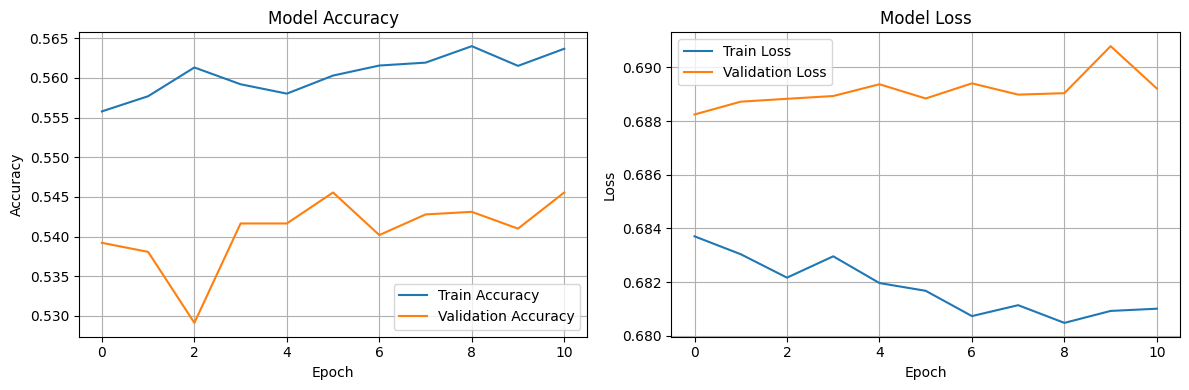

In [21]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [18]:
# Evaluate model on test set
y_pred_proba = model.predict(X_test_seq_scaled, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_test_seq, y_pred)
roc_auc = roc_auc_score(y_test_seq, y_pred_proba)
brier = brier_score_loss(y_test_seq, y_pred_proba)

print("LSTM Model Performance on Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"\nClass distribution in test set:")
print(f"Wins: {np.sum(y_test_seq == 1)}, Losses: {np.sum(y_test_seq == 0)}")


LSTM Model Performance on Test Set:
Accuracy: 0.5364
ROC AUC: 0.5573
Brier Score: 0.2471

Class distribution in test set:
Wins: 3656, Losses: 4026


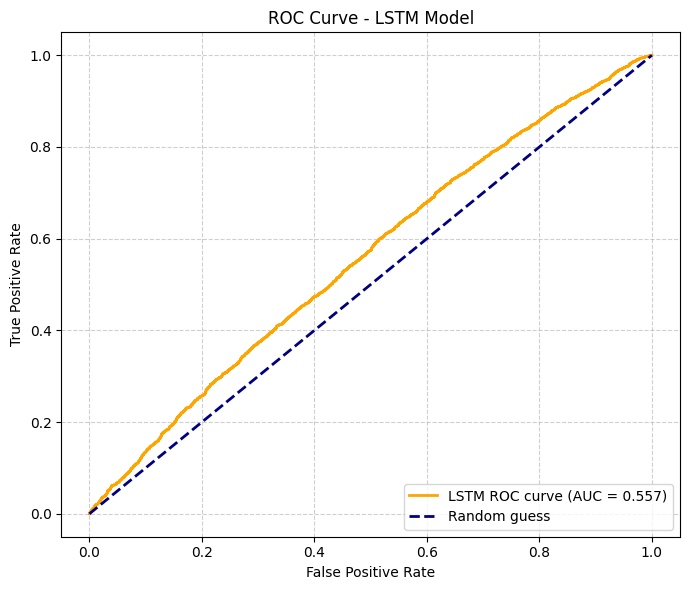

In [19]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_seq, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='orange', linewidth=2,
         label=f'LSTM ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy', linewidth=2, label='Random guess')

plt.title("ROC Curve - LSTM Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


The LSTM model learns from sequences of team performance over time, capturing temporal patterns and momentum. 
Unlike traditional models that use aggregated features, the LSTM can learn complex patterns in how team performance 
evolves across multiple games. This makes it particularly suited for sports prediction where recent form and momentum matter.


In [20]:
# Save the LSTM model and preprocessing objects
model.save('lstm_model.h5')
print("Saved LSTM model to lstm_model.h5")

# Save scaler and metadata
model_bundle = {
    "scaler": scaler,
    "sequence_features": sequence_features,
    "sequence_length": SEQUENCE_LENGTH,
    "model_type": "LSTM"
}

with open("lstm_model_bundle.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

print("Saved model bundle (scaler, features, sequence_length) to lstm_model_bundle.pkl")


Saved LSTM model to lstm_model.h5
Saved model bundle (scaler, features, sequence_length) to lstm_model_bundle.pkl


In [25]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

# ============================================================================
# CUSTOM LOSS FUNCTION
# ============================================================================
def focal_loss(gamma=2., alpha=0.25):
    """
    Focal loss for handling class imbalance
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = keras.backend.epsilon()
        y_pred = keras.backend.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * keras.backend.log(y_pred)
        weight = alpha * y_true * keras.backend.pow((1 - y_pred), gamma)
        loss = weight * cross_entropy
        return keras.backend.mean(keras.backend.sum(loss, axis=1))
    return focal_loss_fixed

# ============================================================================
# MODEL BUILDING FUNCTION
# ============================================================================
def build_improved_lstm_model(sequence_length, n_features, use_bidirectional=True, 
                              use_attention=True, learning_rate=0.001):
    """
    Build an improved LSTM model with multiple enhancements
    
    Args:
        sequence_length: Number of time steps in sequence
        n_features: Number of features per time step
        use_bidirectional: Whether to use bidirectional LSTMs
        use_attention: Whether to add attention mechanism
        learning_rate: Initial learning rate
    """
    keras.backend.clear_session()
    
    if use_attention:
        # Use Functional API for attention mechanism
        inputs = layers.Input(shape=(sequence_length, n_features))
        
        # First LSTM layer
        if use_bidirectional:
            x = layers.Bidirectional(
                layers.LSTM(64, return_sequences=True, 
                           dropout=0.15, recurrent_dropout=0.15,
                           kernel_regularizer=keras.regularizers.l2(0.01))
            )(inputs)
        else:
            x = layers.LSTM(64, return_sequences=True,
                           dropout=0.15, recurrent_dropout=0.15,
                           kernel_regularizer=keras.regularizers.l2(0.01))(inputs)
        
        x = layers.BatchNormalization()(x)
        
        # Attention mechanism
        # Query and value are the same (self-attention)
        attention_output = layers.Attention()([x, x])
        
        # Second LSTM layer
        if use_bidirectional:
            x = layers.Bidirectional(
                layers.LSTM(32, return_sequences=False,
                           dropout=0.15, recurrent_dropout=0.15,
                           kernel_regularizer=keras.regularizers.l2(0.01))
            )(attention_output)
        else:
            x = layers.LSTM(32, return_sequences=False,
                           dropout=0.15, recurrent_dropout=0.15,
                           kernel_regularizer=keras.regularizers.l2(0.01))(attention_output)
        
        x = layers.BatchNormalization()(x)
        
        # Dense layers
        x = layers.Dense(32, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(0.01))(x)
        x = layers.Dropout(0.3)(x)
        
        x = layers.Dense(16, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(0.01))(x)
        x = layers.Dropout(0.2)(x)
        
        # Output layer
        outputs = layers.Dense(1, activation='sigmoid')(x)
        
        model = keras.Model(inputs=inputs, outputs=outputs)
        
    else:
        # Use Sequential API when not using attention
        model = keras.Sequential()
        
        # First LSTM layer
        if use_bidirectional:
            model.add(layers.Bidirectional(
                layers.LSTM(64, return_sequences=True, 
                           dropout=0.15, recurrent_dropout=0.15,
                           kernel_regularizer=keras.regularizers.l2(0.01)),
                input_shape=(sequence_length, n_features)
            ))
        else:
            model.add(layers.LSTM(64, return_sequences=True,
                                 dropout=0.15, recurrent_dropout=0.15,
                                 kernel_regularizer=keras.regularizers.l2(0.01),
                                 input_shape=(sequence_length, n_features)))
        
        model.add(layers.BatchNormalization())
        
        # Second LSTM layer
        if use_bidirectional:
            model.add(layers.Bidirectional(
                layers.LSTM(32, return_sequences=False,
                           dropout=0.15, recurrent_dropout=0.15,
                           kernel_regularizer=keras.regularizers.l2(0.01))
            ))
        else:
            model.add(layers.LSTM(32, return_sequences=False,
                                 dropout=0.15, recurrent_dropout=0.15,
                                 kernel_regularizer=keras.regularizers.l2(0.01)))
        
        model.add(layers.BatchNormalization())
        
        # Dense layers
        model.add(layers.Dense(32, activation='relu',
                              kernel_regularizer=keras.regularizers.l2(0.01)))
        model.add(layers.Dropout(0.3))
        
        model.add(layers.Dense(16, activation='relu',
                              kernel_regularizer=keras.regularizers.l2(0.01)))
        model.add(layers.Dropout(0.2))
        
        # Output layer
        model.add(layers.Dense(1, activation='sigmoid'))
    
    # Compile with multiple metrics
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',  # Can switch to focal_loss() if needed
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    
    return model

# ============================================================================
# TRAINING FUNCTION
# ============================================================================
def train_improved_model(model, X_train, y_train, X_val=None, y_val=None,
                        batch_size=64, epochs=100, use_class_weights=True):
    """
    Train the model with improved callbacks and configuration
    
    Args:
        model: Compiled Keras model
        X_train: Training features
        y_train: Training labels
        X_val: Validation features (optional)
        y_val: Validation labels (optional)
        batch_size: Batch size for training
        epochs: Maximum number of epochs
        use_class_weights: Whether to compute and use class weights
    """
    
    # Compute class weights if requested
    class_weight_dict = None
    if use_class_weights:
        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weight_dict = dict(enumerate(class_weights))
        print(f"Class weights: {class_weight_dict}")
    
    # Define callbacks
    callbacks = [
        # Early stopping on validation AUC
        keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=15,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        
        # Reduce learning rate when plateau
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-7,
            verbose=1
        ),
        
        # Model checkpoint to save best model
        keras.callbacks.ModelCheckpoint(
            'best_nhl_model.keras',
            monitor='val_auc',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        
        # TensorBoard logging (optional)
        keras.callbacks.TensorBoard(
            log_dir='./logs',
            histogram_freq=1
        )
    ]
    
    # Determine validation data
    if X_val is not None and y_val is not None:
        validation_data = (X_val, y_val)
        validation_split = None
    else:
        validation_data = None
        validation_split = 0.2
    
    # Train the model
    history = model.fit(
        X_train,
        y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=validation_data,
        validation_split=validation_split,
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )
    
    return history

# ============================================================================
# EVALUATION FUNCTION
# ============================================================================
def evaluate_model(model, X_test, y_test, threshold=0.5):
    """
    Comprehensive model evaluation
    """
    # Get predictions
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > threshold).astype(int)
    
    # Calculate metrics
    print("\n" + "="*60)
    print("MODEL EVALUATION RESULTS")
    print("="*60)
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                               target_names=['Away Win', 'Home Win']))
    
    # Confusion matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    # AUC Score
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\nROC AUC Score: {auc:.4f}")
    
    # Accuracy by prediction confidence
    high_conf_mask = (y_pred_proba > 0.6) | (y_pred_proba < 0.4)
    if high_conf_mask.sum() > 0:
        high_conf_acc = (y_pred[high_conf_mask.flatten()] == 
                        y_test[high_conf_mask.flatten()]).mean()
        print(f"High Confidence Accuracy (>60% or <40%): {high_conf_acc:.4f}")
        print(f"High Confidence Predictions: {high_conf_mask.sum()} / {len(y_test)}")
    
    return y_pred_proba, y_pred

# ============================================================================
# VISUALIZATION FUNCTION
# ============================================================================
def plot_training_history(history):
    """
    Plot training history
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Train Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0, 1].set_title('Model Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # AUC
    axes[1, 0].plot(history.history['auc'], label='Train AUC')
    axes[1, 0].plot(history.history['val_auc'], label='Val AUC')
    axes[1, 0].set_title('Model AUC')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Learning Rate
    if 'lr' in history.history:
        axes[1, 1].plot(history.history['lr'])
        axes[1, 1].set_title('Learning Rate')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# ENSEMBLE PREDICTION FUNCTION
# ============================================================================
def create_ensemble_predictions(X_train, y_train, X_test, y_test,
                               sequence_length, n_features, n_models=5):
    """
    Create ensemble of models with different seeds for robust predictions
    """
    predictions = []
    models = []
    
    print(f"\nTraining ensemble of {n_models} models...")
    
    for i in range(n_models):
        print(f"\n{'='*60}")
        print(f"Training Model {i+1}/{n_models}")
        print(f"{'='*60}")
        
        # Set seed for reproducibility
        tf.random.set_seed(42 + i)
        np.random.seed(42 + i)
        
        # Build and train model
        model = build_improved_lstm_model(sequence_length, n_features)
        history = train_improved_model(model, X_train, y_train, 
                                      epochs=50, batch_size=64)
        
        # Get predictions
        pred = model.predict(X_test, verbose=0)
        predictions.append(pred)
        models.append(model)
    
    # Average predictions
    ensemble_pred_proba = np.mean(predictions, axis=0)
    ensemble_pred = (ensemble_pred_proba > 0.5).astype(int)
    
    # Evaluate ensemble
    print("\n" + "="*60)
    print("ENSEMBLE MODEL EVALUATION")
    print("="*60)
    print("\nClassification Report:")
    print(classification_report(y_test, ensemble_pred,
                               target_names=['Away Win', 'Home Win']))
    
    auc = roc_auc_score(y_test, ensemble_pred_proba)
    print(f"\nEnsemble ROC AUC Score: {auc:.4f}")
    
    return models, ensemble_pred_proba

# ============================================================================
# MAIN EXECUTION EXAMPLE
# ============================================================================
if __name__ == "__main__":
    # Example usage (replace with your actual data)
    # Assuming you have: X_train_seq_scaled, y_train_seq, X_test_seq_scaled, y_test_seq
    
    # Example parameters
    SEQUENCE_LENGTH = 10  # Replace with your actual sequence length
    N_FEATURES = 8  # Replace with len(sequence_features)
    
    print("Building improved LSTM model...")
    model = build_improved_lstm_model(
        sequence_length=SEQUENCE_LENGTH,
        n_features=N_FEATURES,
        use_bidirectional=True,
        use_attention=True,
        learning_rate=0.001
    )
    
    model.summary()

Building improved LSTM model...



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 10, 128)   │     37,376 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 128)   │        512 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 10, 128)   │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     41,216 │ attention[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ bidirectional_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         17 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 81,985 (320.25 KB)

 Trainable params: 81,601 (318.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [26]:
print("\nTraining model...")
history = train_improved_model(
    model, 
    X_train_seq_scaled, 
    y_train_seq,
    batch_size=64,
    epochs=100,
    use_class_weights=True
)




Training model...
Class weights: {0: np.float64(0.9111018858972838), 1: np.float64(1.108121754183497)}
Epoch 1/100
385/385 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5097 - auc: 0.5150 - loss: 2.8357 - precision: 0.4641 - recall: 0.5277
Epoch 1: val_auc improved from None to 0.55068, saving model to best_nhl_model.keras
385/385 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step - accuracy: 0.5231 - auc: 0.5238 - loss: 1.9520 - precision: 0.4675 - recall: 0.4946 - val_accuracy: 0.5369 - val_auc: 0.5507 - val_loss: 0.9845 - val_precision: 0.5217 - val_recall: 0.2119 - learning_rate: 0.0010
Epoch 2/100
384/385 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5492 - auc: 0.5519 - loss: 0.8831 - precision: 0.4901 - recall: 0.3703
Epoch 2: val_auc did not improve from 0.55068
385/385 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.5445 - auc: 0.5499 - loss: 0.8166 - precision: 0.4866 - recall: 0.3822 - val_accuracy: 0.5342 - val_auc: 0.5404 - val_loss: 0.7310 - val_precision: 0.5071 - val_recall: 0.42

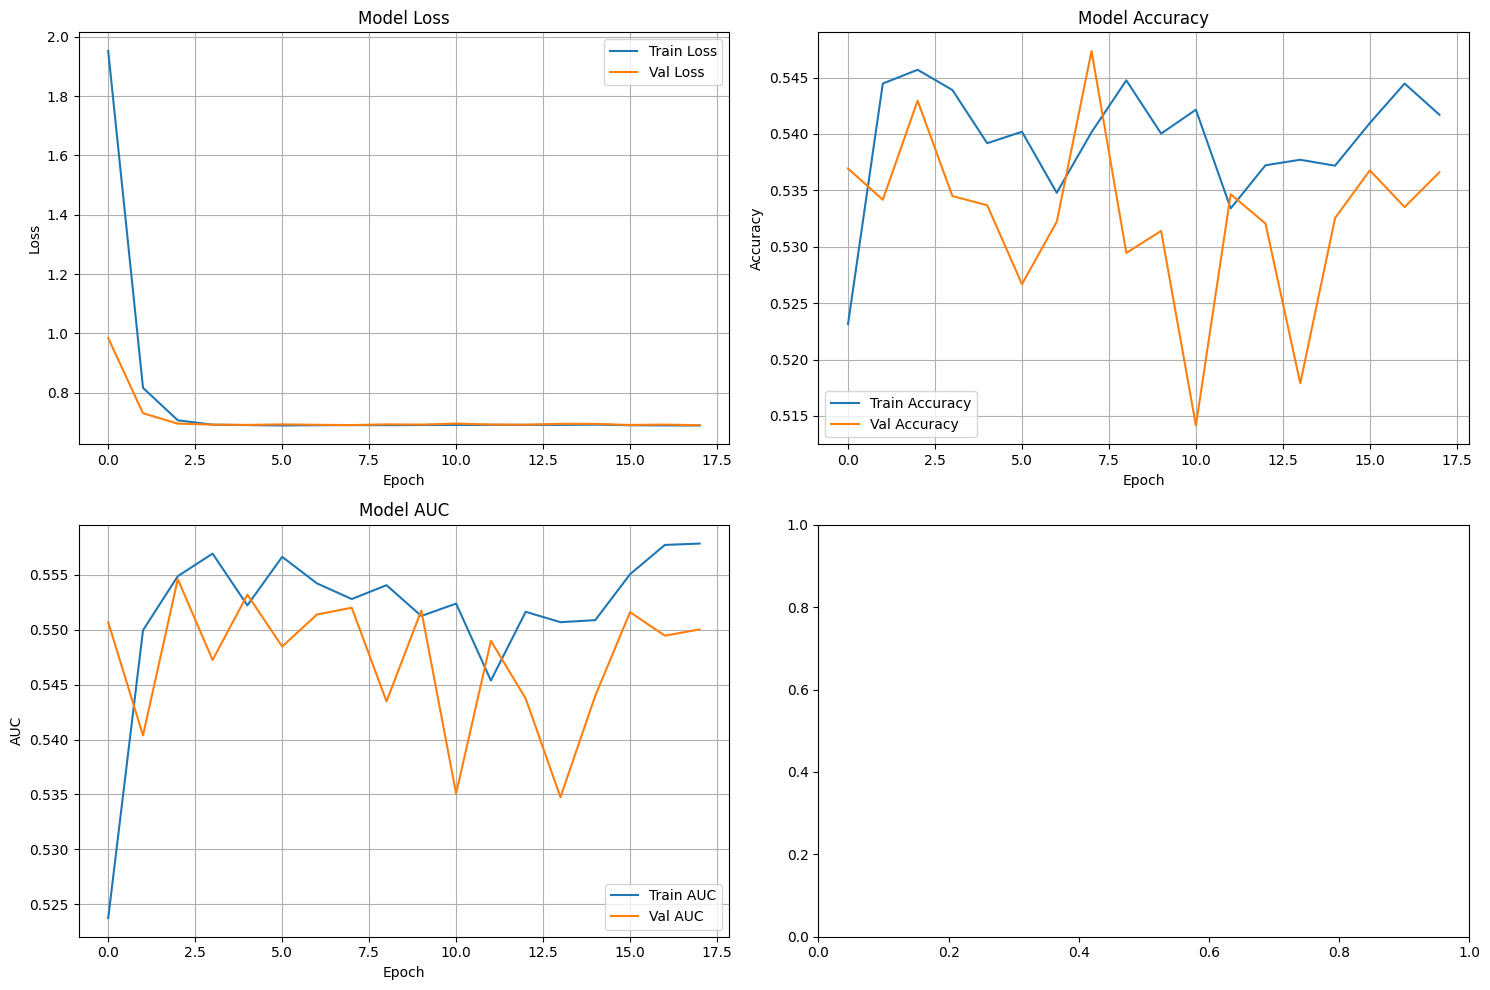


Evaluating model...
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step

MODEL EVALUATION RESULTS

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.56      0.60      0.58      4026
    Home Win       0.52      0.47      0.50      3656

    accuracy                           0.54      7682
   macro avg       0.54      0.54      0.54      7682
weighted avg       0.54      0.54      0.54      7682


Confusion Matrix:
[[2423 1603]
 [1923 1733]]

ROC AUC Score: 0.5594


In [28]:
plot_training_history(history)
print("\nEvaluating model...")
y_pred_proba, y_pred = evaluate_model(model, X_test_seq_scaled, y_test_seq)


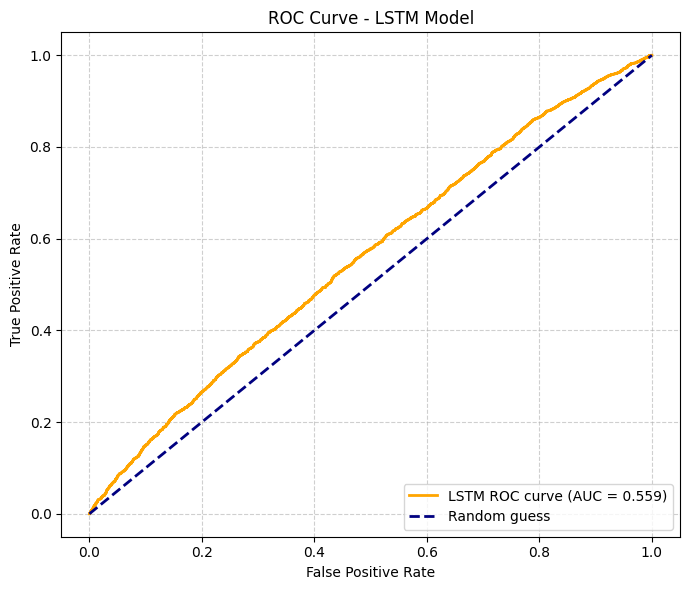

In [29]:
fpr, tpr, thresholds = roc_curve(y_test_seq, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='orange', linewidth=2,
         label=f'LSTM ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy', linewidth=2, label='Random guess')

plt.title("ROC Curve - LSTM Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:

models, ensemble_pred = create_ensemble_predictions(
    X_train_seq_scaled, y_train_seq,
    X_test_seq_scaled, y_test_seq,
    SEQUENCE_LENGTH, N_FEATURES,
    n_models=5
)